🌳 Árbol de Decisión para Regresión — Predicción de IMDb Rating

In [1]:
# ── CELDA 0: Configuración de rutas ──────────────────────────
import os
import sys

# Ruta raíz del proyecto
ROOT_DIR = os.path.abspath("..")

# Ruta ETL
ETL_DIR = os.path.join(ROOT_DIR, "Etl-Proyecto")

# Agregar Etl-Proyecto al PATH
if ETL_DIR not in sys.path:
    sys.path.append(ETL_DIR)

# Carpetas de gráficas
GRAFICAS_DIR = os.path.join(
    ROOT_DIR,
    "data",
    "graficas",
    "arbol_de_decision"
)

os.makedirs(GRAFICAS_DIR, exist_ok=True)

print("✅ Configuración completada")
print(f"📁 ROOT_DIR: {ROOT_DIR}")
print(f"📁 ETL_DIR: {ETL_DIR}")
print(f"📁 GRAFICAS_DIR: {GRAFICAS_DIR}")

print("\n📂 Contenido ETL_DIR:")
print(os.listdir(ETL_DIR))

✅ Configuración completada
📁 ROOT_DIR: /home/desarrollo/Grupo6_Obregon_Heredia_MD1
📁 ETL_DIR: /home/desarrollo/Grupo6_Obregon_Heredia_MD1/Etl-Proyecto
📁 GRAFICAS_DIR: /home/desarrollo/Grupo6_Obregon_Heredia_MD1/data/graficas/arbol_de_decision

📂 Contenido ETL_DIR:
['alembic.ini', 'scripts', 'data', 'README.md', '.env', 'create_db.py', 'peliculas.db', 'dashboard_interactive.py', 'alembic', 'notebooks', 'dashboard_app.py', 'logs']


# 🌳 Árbol de Decisión — Regresión de IMDb Rating

Análisis comparativo usando DecisionTreeRegressor entrenado con tres particiones distintas (80/20, 70/30, 60/40) para evaluar la robustez del modelo predictivo.

### 🎯 Variable predictora (X)

#### anio 

### 🎯 Variable objetivo (Y)

#### imdb_rating

### 🗄️ Fuente de datos

Tabla PostgreSQL: registro_peliculas

In [2]:
# ── CELDA 1: Importaciones ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sqlalchemy import text
from scripts.database import engine

# Estilo visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11
})

print("✅ Librerías importadas correctamente")
print(f"📦 pandas  {pd.__version__}")
print(f"📦 numpy   {np.__version__}")
print(f"📦 seaborn {sns.__version__}")

✅ Librerías importadas correctamente
📦 pandas  2.3.3
📦 numpy   1.26.4
📦 seaborn 0.13.2


In [3]:
# ── CELDA 2: Extracción SQL ──────────────────────────────────
QUERY = """
SELECT
    anio,
    imdb_rating
FROM registro_peliculas
WHERE imdb_rating IS NOT NULL
  AND anio IS NOT NULL
ORDER BY anio;
"""

with engine.connect() as conn:
    df = pd.read_sql(text(QUERY), conn)

# Renombrar columnas
df.rename(columns={
    'anio': 'Anio',
    'imdb_rating': 'IMDb_Rating'
}, inplace=True)

print("✅ Datos cargados correctamente desde PostgreSQL")
print(f"📊 Filas: {df.shape[0]:,}")
print(f"📊 Columnas: {df.shape[1]}")

print("\n📋 Valores nulos:")
print(df.isnull().sum())

df.head()

✅ Datos cargados correctamente desde PostgreSQL
📊 Filas: 528
📊 Columnas: 2

📋 Valores nulos:
Anio           0
IMDb_Rating    0
dtype: int64


,Anio,IMDb_Rating
0,1939,6.1
1,1940,6.7
2,1942,8.5
3,1943,8.5
4,1946,7.9


In [4]:
# ── CELDA 3: Variables predictoras y objetivo ───────────────
X = df[['Anio']].values
y = df['IMDb_Rating'].values

print("✅ Variables preparadas correctamente")
print(f"📐 Shape X: {X.shape}")
print(f"📐 Shape y: {y.shape}")

print("\n📊 Estadísticas descriptivas:")
display(df.describe().round(2))

✅ Variables preparadas correctamente
📐 Shape X: (528, 1)
📐 Shape y: (528,)

📊 Estadísticas descriptivas:


,Anio,IMDb_Rating
count,528.00,528.00
mean,2003.35,7.33
std,15.58,1.19
min,1939.00,1.60
25%,2001.00,6.60
50%,2009.00,7.60
75%,2011.00,8.20
max,2021.00,9.30


In [14]:
# ── CELDA 4: Función de evaluación ───────────────────────────
def evaluar_split(X, y, test_size, split_label, resultados_globales):
    
    train_pct = int((1 - test_size) * 100)
    test_pct = int(test_size * 100)

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42
    )

    print(f"\n{'='*60}")
    print(f"🌳 {split_label} — {train_pct}% Train / {test_pct}% Test")
    print(f"{'='*60}")

    # Modelo
    modelo = DecisionTreeRegressor(max_depth=mejor_depth, random_state=42)
    modelo.fit(X_train, y_train)

    print("✅ Modelo entrenado correctamente")

    # Predicción
    y_pred = modelo.predict(X_test)

    # Métricas
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    print("\n📊 MÉTRICAS")
    print(f"R²   : {r2:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")

    resultados_globales.append({
        'Split': split_label,
        'Train%': train_pct,
        'Test%': test_pct,
        'R²': round(r2, 4),
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4)
    })

    # ── Gráficas ─────────────────────────────────────────────
    residuos = y_test - y_pred

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Residuos
    axes[0].scatter(y_pred, residuos, alpha=0.5)
    axes[0].axhline(0, linestyle='--')
    axes[0].set_title('Gráfico de Residuos')
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Residuo')

    # Predicción vs Real
    axes[1].scatter(y_test, y_pred, alpha=0.5)
    axes[1].plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle='--'
    )
    axes[1].set_title('Predicción vs Valor Real')
    axes[1].set_xlabel('Valor Real')
    axes[1].set_ylabel('Predicción')

    plt.tight_layout()

    archivo = os.path.join(
        GRAFICAS_DIR,
        f"dt_regresion_{split_label.replace('/', '-')}.png"
    )

    plt.savefig(archivo, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"💾 Gráfica guardada → {archivo}")

    return modelo, y_test, y_pred


# Contenedor global
resultados_globales = []

print("✅ Función evaluar_split creada correctamente")

✅ Función evaluar_split creada correctamente


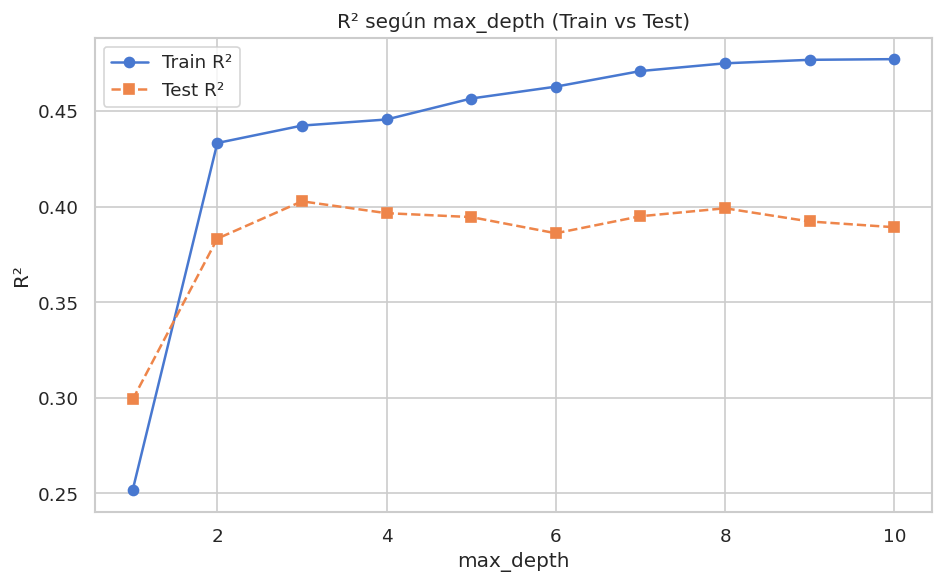

✅ Mejor max_depth según Test R²: 3
   Train R²: 0.4424
   Test  R²: 0.4028


In [15]:
# ── CELDA 4b: Inicialización + búsqueda max_depth ────────────

resultados_globales = []

# Buscar mejor max_depth antes de evaluar splits
profundidades = range(1, 11)
scores_train = []
scores_test  = []

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, random_state=42
)

for d in profundidades:
    m = DecisionTreeRegressor(max_depth=d, random_state=42)
    m.fit(X_tr, y_tr)
    scores_train.append(r2_score(y_tr, m.predict(X_tr)))
    scores_test.append(r2_score(y_te, m.predict(X_te)))

plt.figure(figsize=(8, 5))
plt.plot(profundidades, scores_train, marker='o', label='Train R²')
plt.plot(profundidades, scores_test,  marker='s', label='Test R²', linestyle='--')
plt.title('R² según max_depth (Train vs Test)')
plt.xlabel('max_depth')
plt.ylabel('R²')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(GRAFICAS_DIR, 'dt_max_depth_regresion.png'), dpi=150, bbox_inches='tight')
plt.show()

mejor_depth = scores_test.index(max(scores_test)) + 1
print(f"✅ Mejor max_depth según Test R²: {mejor_depth}")
print(f"   Train R²: {scores_train[mejor_depth-1]:.4f}")
print(f"   Test  R²: {scores_test[mejor_depth-1]:.4f}")


🌳 Split 80/20 — 80% Train / 20% Test
✅ Modelo entrenado correctamente

📊 MÉTRICAS
R²   : 0.4028
MSE  : 0.8652
RMSE : 0.9302
MAE  : 0.5927


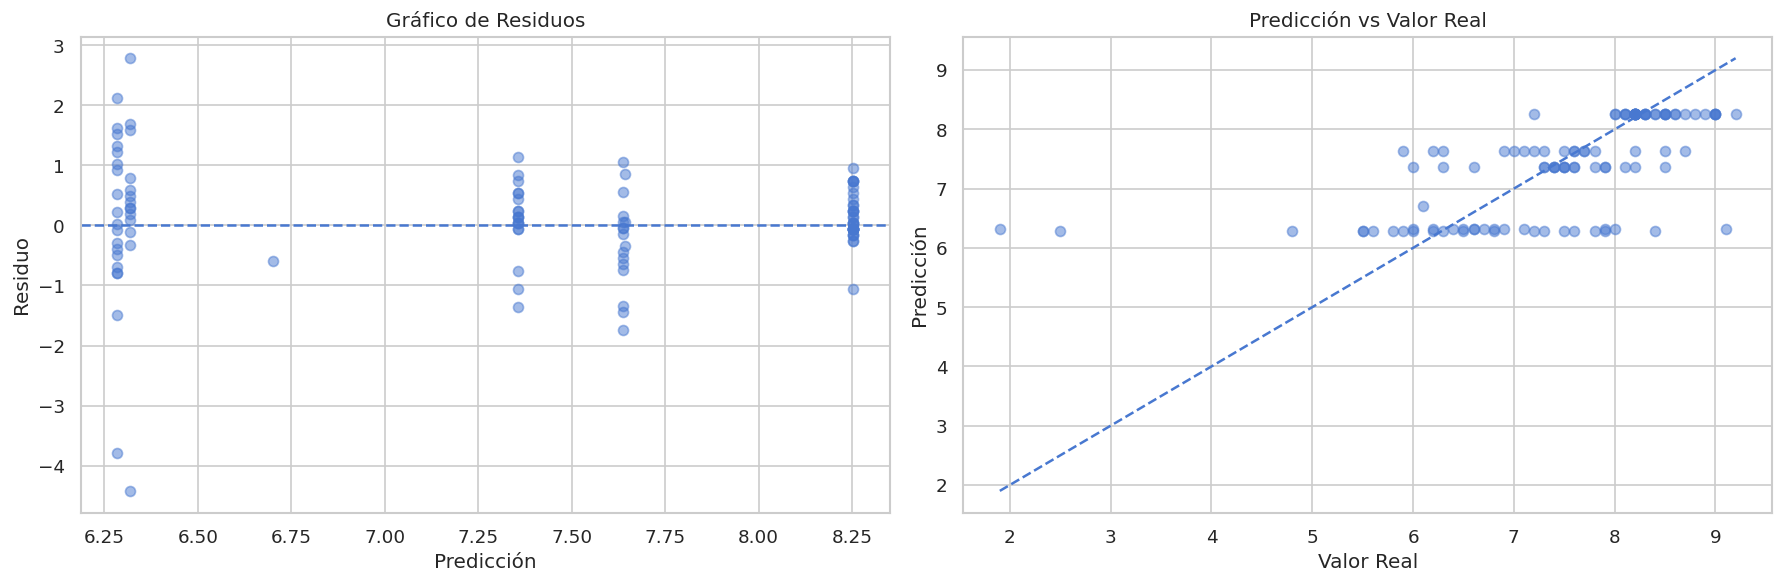

💾 Gráfica guardada → /home/desarrollo/Grupo6_Obregon_Heredia_MD1/data/graficas/arbol_de_decision/dt_regresion_Split 80-20.png
✅ Split 80/20 ejecutado correctamente


In [16]:
# ── CELDA 5: Split 80/20 ────────────────────────────────────
modelo_s1, y_test_s1, y_pred_s1 = evaluar_split(
    X,
    y,
    test_size=0.20,
    split_label='Split 80/20',
    resultados_globales=resultados_globales
)

print("✅ Split 80/20 ejecutado correctamente")


🌳 Split 70/30 — 70% Train / 30% Test
✅ Modelo entrenado correctamente

📊 MÉTRICAS
R²   : 0.4496
MSE  : 0.7857
RMSE : 0.8864
MAE  : 0.6047


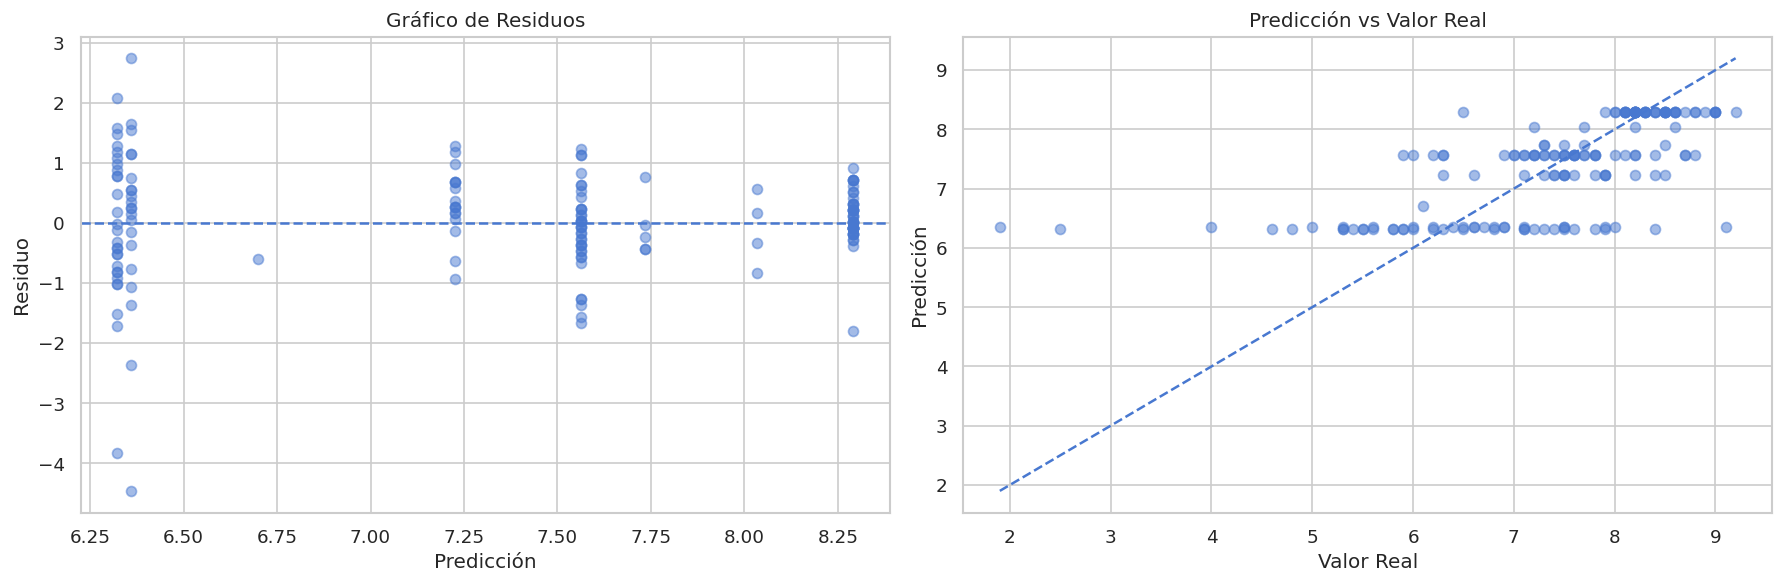

💾 Gráfica guardada → /home/desarrollo/Grupo6_Obregon_Heredia_MD1/data/graficas/arbol_de_decision/dt_regresion_Split 70-30.png
✅ Split 70/30 ejecutado correctamente


In [17]:
# ── CELDA 6: Split 70/30 ────────────────────────────────────
modelo_s2, y_test_s2, y_pred_s2 = evaluar_split(
    X,
    y,
    test_size=0.30,
    split_label='Split 70/30',
    resultados_globales=resultados_globales
)

print("✅ Split 70/30 ejecutado correctamente")


🌳 Split 60/40 — 60% Train / 40% Test
✅ Modelo entrenado correctamente

📊 MÉTRICAS
R²   : 0.3972
MSE  : 0.8957
RMSE : 0.9464
MAE  : 0.6489


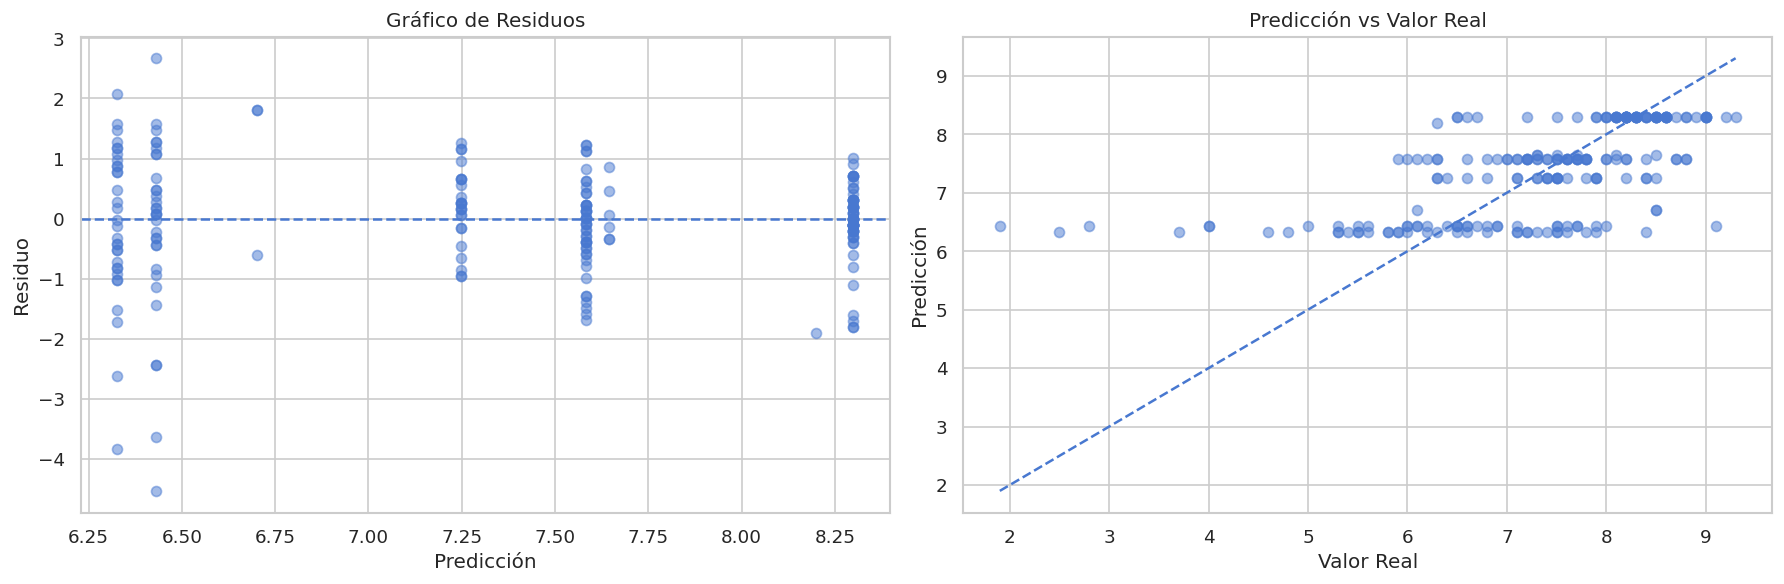

💾 Gráfica guardada → /home/desarrollo/Grupo6_Obregon_Heredia_MD1/data/graficas/arbol_de_decision/dt_regresion_Split 60-40.png
✅ Split 60/40 ejecutado correctamente


In [18]:
# ── CELDA 7: Split 60/40 ────────────────────────────────────
modelo_s3, y_test_s3, y_pred_s3 = evaluar_split(
    X,
    y,
    test_size=0.40,
    split_label='Split 60/40',
    resultados_globales=resultados_globales
)

print("✅ Split 60/40 ejecutado correctamente")

In [19]:
# ── CELDA 8: Resumen comparativo ────────────────────────────
df_resumen = pd.DataFrame(resultados_globales)

print("=" * 65)
print("📊 TABLA COMPARATIVA — TRES SPLITS")
print("=" * 65)

display(df_resumen)

print("✅ Tabla comparativa generada correctamente")

📊 TABLA COMPARATIVA — TRES SPLITS


,Split,Train%,Test%,R²,MSE,RMSE,MAE
0,Split 80/20,80,20,0.4028,0.8652,0.9302,0.5927
1,Split 70/30,70,30,0.4496,0.7857,0.8864,0.6047
2,Split 60/40,60,40,0.3972,0.8957,0.9464,0.6489


✅ Tabla comparativa generada correctamente


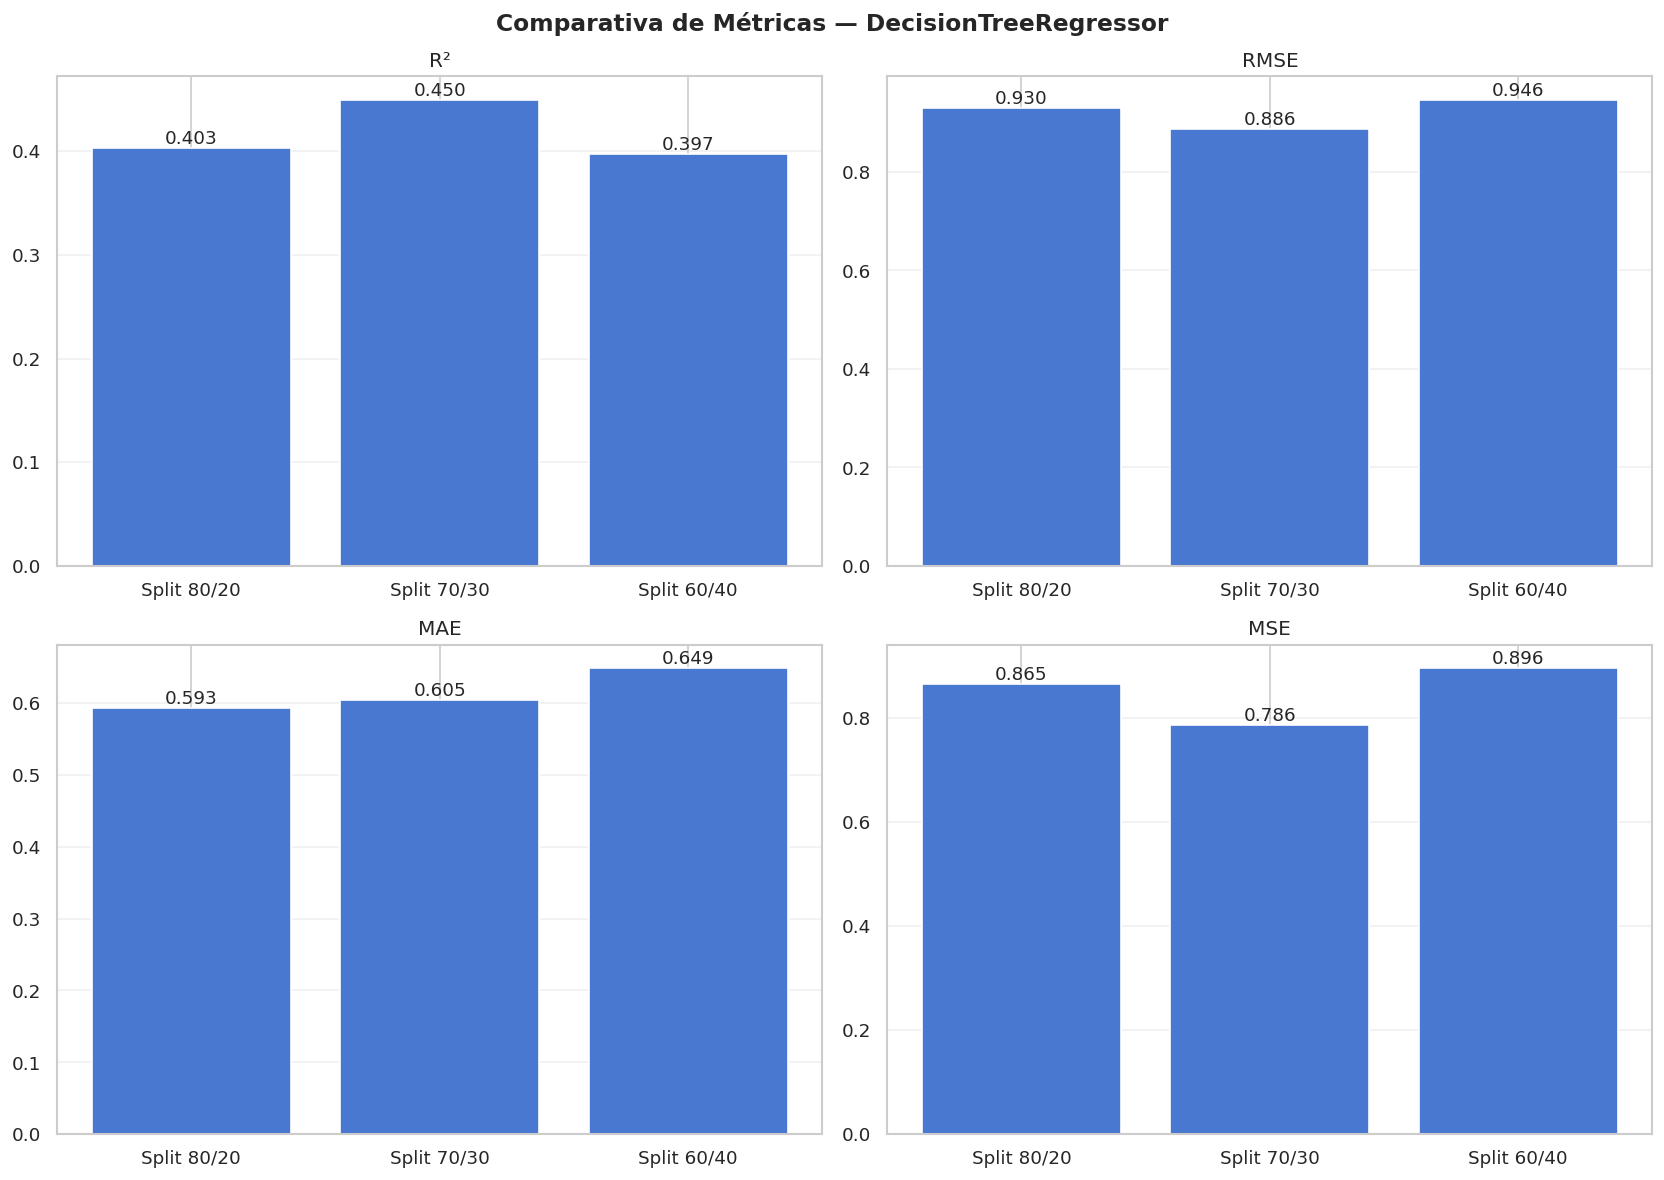

💾 Gráfica guardada → /home/desarrollo/Grupo6_Obregon_Heredia_MD1/data/graficas/arbol_de_decision/dt_metricas_comparativas.png
✅ Comparativa de métricas completada


In [20]:
# ── CELDA 9: Comparativa de métricas ────────────────────────
metricas = ['R²', 'RMSE', 'MAE', 'MSE']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fig.suptitle(
    'Comparativa de Métricas — DecisionTreeRegressor',
    fontsize=14,
    fontweight='bold'
)

for ax, metrica in zip(axes.flat, metricas):

    valores = df_resumen[metrica]

    bars = ax.bar(df_resumen['Split'], valores)

    ax.set_title(metrica)
    ax.grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, valores):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{val:.3f}',
            ha='center',
            va='bottom'
        )

plt.tight_layout()

archivo_metricas = os.path.join(
    GRAFICAS_DIR,
    'dt_metricas_comparativas.png'
)

plt.savefig(archivo_metricas, dpi=150, bbox_inches='tight')

plt.show()

print(f"💾 Gráfica guardada → {archivo_metricas}")
print("✅ Comparativa de métricas completada")

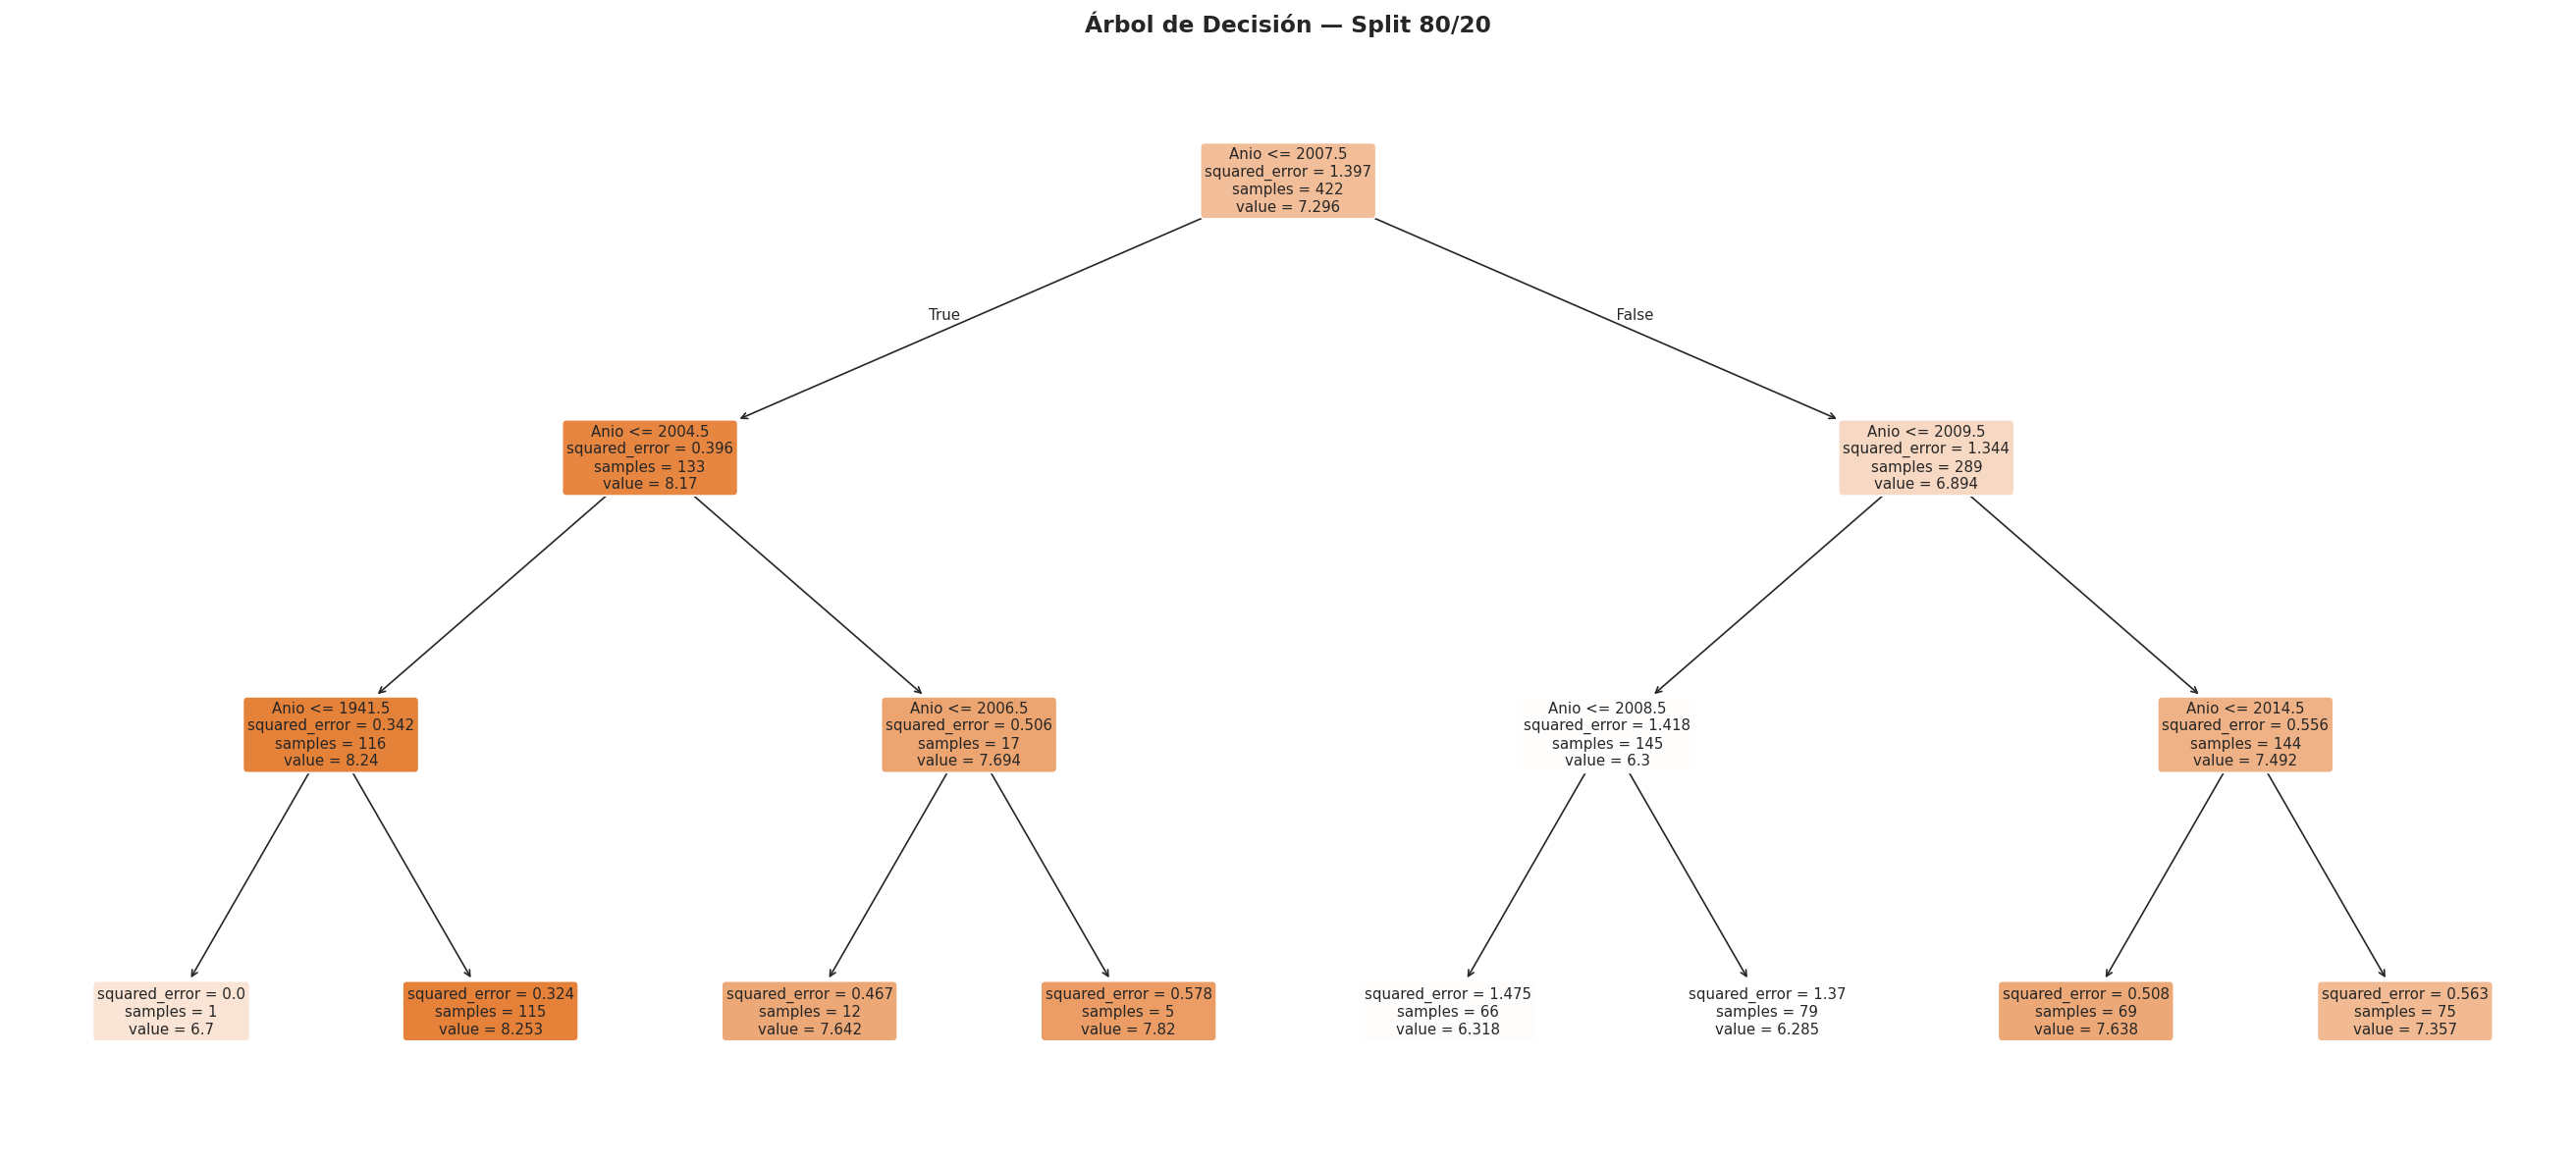

💾 Árbol guardado → /home/desarrollo/Grupo6_Obregon_Heredia_MD1/data/graficas/arbol_de_decision/dt_arbol_regresion.png
✅ Visualización del árbol completada


In [21]:
# ── CELDA 10: Visualización del árbol ───────────────────────
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(22, 10))

plot_tree(
    modelo_s1,
    max_depth=4,
    feature_names=['Anio'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)

ax.set_title(
    'Árbol de Decisión — Split 80/20',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

archivo_arbol = os.path.join(
    GRAFICAS_DIR,
    'dt_arbol_regresion.png'
)

plt.savefig(archivo_arbol, dpi=150, bbox_inches='tight')

plt.show()

print(f"💾 Árbol guardado → {archivo_arbol}")
print("✅ Visualización del árbol completada")

In [22]:
# ── CELDA 11: Reglas del árbol ──────────────────────────────
from sklearn.tree import export_text

reglas = export_text(
    modelo_s1,
    feature_names=['Anio']
)

print("=" * 60)
print("📖 REGLAS DEL ÁRBOL")
print("=" * 60)

print(reglas)

print("✅ Reglas del árbol generadas correctamente")

📖 REGLAS DEL ÁRBOL
|--- Anio <= 2007.50
|   |--- Anio <= 2004.50
|   |   |--- Anio <= 1941.50
|   |   |   |--- value: [6.70]
|   |   |--- Anio >  1941.50
|   |   |   |--- value: [8.25]
|   |--- Anio >  2004.50
|   |   |--- Anio <= 2006.50
|   |   |   |--- value: [7.64]
|   |   |--- Anio >  2006.50
|   |   |   |--- value: [7.82]
|--- Anio >  2007.50
|   |--- Anio <= 2009.50
|   |   |--- Anio <= 2008.50
|   |   |   |--- value: [6.32]
|   |   |--- Anio >  2008.50
|   |   |   |--- value: [6.28]
|   |--- Anio >  2009.50
|   |   |--- Anio <= 2014.50
|   |   |   |--- value: [7.64]
|   |   |--- Anio >  2014.50
|   |   |   |--- value: [7.36]

✅ Reglas del árbol generadas correctamente
